# Distributed Harmonic Extension: Tracking Without a Central Solver

Multi-agent tracking on a cellular sheaf reduces, at every control step, to a
**harmonic extension**: pin the targets as boundary data, and solve

$$
q^\star = H^{-1} B p
$$

for the cochain that minimises sheaf Dirichlet energy on the free (agent) cells.
Every agent then descends its own disagreement, $u_i = -k\,(x_i - q^\star_i)$.

Written that way, $H^{-1}Bp$ is a **global sparse solve**, which quietly assumes a
central computer that knows the whole fleet. That assumption is exactly what we want to
remove. On real hardware there is no hub, each vehicle carries its own flight computer,
and a vehicle can only talk to its neighbours.

This example solves the *same* harmonic extension by **message passing between separate
agent processes**. No agent ever sees the whole factorisation. We check that the
resulting closed-loop trajectories are **bit-for-bit identical** to the centralised
controller, and we look at what each agent actually has to store.

The theory behind every step here, the multifrontal factorisation, the tree partition,
and the message schedule, is written up in the
Distributed Sheaf Solve feature guide.

## How it works

The chordal factorisation of $H$ produces a **clique tree**. Each node of that tree is
a *supernode* owning a dense diagonal block $D_{11}$ and an off-diagonal block
$L_{21}$. The solve is already *scheduled by the tree*:

- the **forward** pass is a bottom-up reduction, where a node needs only its children's contributions,
- the **backward** pass is a top-down broadcast, where a node needs only its parent's.

So disjoint subtrees are independent. `partition_tree` cuts the clique tree into connected
rooted subtrees, one per agent process, and because a cut only ever falls on an existing
parent/child edge, each chunk has exactly **one** edge to its parent chunk. The number of
cross-process messages is therefore provably minimal.

In [1]:
using CellularSheaves
using CellularSheaves.NetworkSheaves.DistributedSolve
using CliqueTrees.Multifrontal
using LinearAlgebra, SparseArrays, Plots, Printf, Distributed
import CellularSheaves.NetworkSheaves.EuclideanSheaves: _harmonic_extension_restricted_laplacian

A single house style for every figure below, matching the other control examples.

In [2]:
default(framestyle = :box, grid = true, gridalpha = 0.18, gridstyle = :dot,
    titlefontsize = 10, guidefontsize = 9, legendfontsize = 8, tickfontsize = 8,
    markerstrokewidth = 0, size = (720, 340))

const RING_A, RING_B = :steelblue, :darkorange       # house agent palette
const TARGET_A, TARGET_B = :gray35, :black           # house target palette
const PALETTE = [:steelblue, :darkorange, :green, :crimson]
proc_color(w) = PALETTE[mod1(w, length(PALETTE))]

proc_color (generic function with 1 method)

## The tracking sheaf

Twelve agents in two escort rings of six, joined by a single bridge edge, each ring pinned
to its own target. The two targets orbit in **opposite** directions, so the rings sweep past
one another. Identity restriction maps on the consensus edges, identity pinning on the
tracking edges.

In [3]:
const NA, NT = 12, 2
const TV1, TV2 = NA + 1, NA + 2
const D = 3
const I3 = Matrix{Float64}(I, D, D)

consensus_edges = [(1,2),(2,3),(3,4),(4,5),(5,6),(6,1),
                   (7,8),(8,9),(9,10),(10,11),(11,12),(12,7),
                   (1,7)]

sheaf = EuclideanSheaf{Float64}(fill(D, NA + NT))
for (i, j) in consensus_edges
    add_sheaf_edge!(sheaf, i, j, I3, I3)
end
for i in 1:6
    add_sheaf_edge!(sheaf, i, TV1, I3, I3)
end
for i in 7:12
    add_sheaf_edge!(sheaf, i, TV2, I3, I3)
end

target1(t) = [2cos(0.4t), 2sin(0.4t), 1.5 + 0.3sin(0.8t)]
target2(t) = [2cos(-0.4t + pi), 2sin(-0.4t + pi), 1.5 + 0.3sin(-0.8t + pi)]

target2 (generic function with 1 method)

## Factorise once, partition once

The sheaf topology is fixed, so the chordal factorisation of the agent block $H$ is
computed **once**, before the vehicles ever move. `partition_tree` then hands each agent
process its own slice.

In [4]:
boundary0 = Dict(TV1 => target1(0.0), TV2 => target2(0.0))
_, _, H, B = _harmonic_extension_restricted_laplacian(sheaf, boundary0)

F = cholesky!(ChordalCholesky(sparse(H)), NoPivot())
Lfac = F.L
partition = partition_tree(Lfac, 6)

nsuper = length(partition.owner)
nchunk = length(partition.chunks)
ncut = length(partition.cut_edges)

@printf("interior dofs      : %d\n", size(H, 1))
@printf("clique-tree nodes  : %d supernodes\n", nsuper)
@printf("agent processes    : %d chunks\n", nchunk)
@printf("cross-process edges: %d  (= chunks - roots, provably minimal)\n", ncut)

interior dofs      : 36
clique-tree nodes  : 9 supernodes
agent processes    : 3 chunks
cross-process edges: 2  (= chunks - roots, provably minimal)


## Memory per agent

This is the whole point. Each agent stores only the $D_{11}$ / $L_{21}$ blocks for the
supernodes it owns, and one colour is one agent process. The chunks **partition** the factor
exactly, so no block is stored twice.

centralised factor :     2.46 KB
worst agent        :     1.05 KB  (42.9% of centralised)
duplication        :     0.00 %  (0% = exact partition)


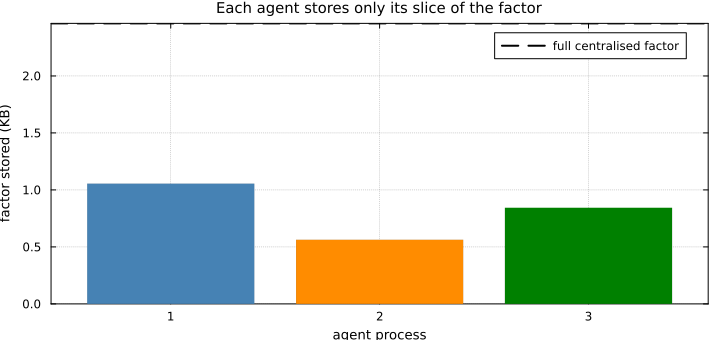

In [5]:
wds = [worker_factorization(Lfac, partition, w) for w in 1:nchunk]
central_bytes = (length(Lfac.Dval) + length(Lfac.Lval)) * sizeof(Float64)
agent_bytes = [(length(wd.Dval) + length(wd.Lval)) * sizeof(Float64) for wd in wds]

@printf("centralised factor : %8.2f KB\n", central_bytes / 1024)
@printf("worst agent        : %8.2f KB  (%.1f%% of centralised)\n",
        maximum(agent_bytes) / 1024, 100 * maximum(agent_bytes) / central_bytes)
@printf("duplication        : %8.2f %%  (0%% = exact partition)\n",
        100 * (sum(agent_bytes) - central_bytes) / central_bytes)

bar(1:nchunk, agent_bytes ./ 1024;
    color = proc_color.(1:nchunk), linewidth = 0, legend = :topright,
    xticks = 1:nchunk, xlabel = "agent process", ylabel = "factor stored (KB)",
    title = "Each agent stores only its slice of the factor", label = "")
hline!([central_bytes / 1024]; linestyle = :dash, color = :black, linewidth = 2,
       label = "full centralised factor")

## Closed-loop tracking, solved by message passing

Now the control loop. At each step the targets move, and the fleet must recompute
$q^\star$. We run it two ways:

- **centralised**, where one process factorises and solves $H q^\star = Bp$ directly,
- **distributed**, where each agent process runs its own chunk's forward/backward sweep,
  exchanging only boundary corrections across cut edges over `RemoteChannel`s.

Nothing else differs. The control law each agent applies is the same sheaf feedback.

In [6]:
workers_pids = addprocs(nchunk; exeflags = "--project=$(Base.active_project())")
@everywhere workers_pids using CellularSheaves

The chordal factorisation applies an internal fill-reducing permutation, so the tree solve
runs in the *permuted* space, $H = P^\top L L^\top P$. The distributed sweeps compute
$(LL^\top)^{-1}$, and the permutation is undone on either side of them.

In [7]:
function harmonic_reference(t, mode)
    xB = vcat(target1(t), target2(t))
    rhs = Vector(-B * xB)
    if mode === :centralised
        return Matrix(H) \ rhs
    else
        rhs_p = Vector(F.P' \ rhs)
        y = distributed_tree_solve(Lfac, rhs_p, 6; pids = workers_pids)
        return F.P \ y
    end
end

const DT, STEPS, GAIN = 0.05, 240, 2.5

function rollout(mode)
    x = zeros(size(H, 1))
    traj = zeros(size(H, 1), STEPS)
    err = zeros(STEPS)
    for step in 1:STEPS
        t = step * DT
        q = harmonic_reference(t, mode)
        x .+= DT .* (GAIN .* (q .- x))
        traj[:, step] = x
        err[step] = norm(x - q) / sqrt(NA)
    end
    traj, err
end

traj_c, err_c = rollout(:centralised)
traj_d, err_d = rollout(:distributed)

divergence = maximum(abs.(traj_c .- traj_d))
@printf("max |x_centralised - x_distributed| over the whole rollout: %.3e\n", divergence)
@printf("%s\n", divergence < 1e-9 ?
        "The distributed solve reproduces the centralised controller EXACTLY." :
        "TRAJECTORIES DIVERGE, something is wrong.")

max |x_centralised - x_distributed| over the whole rollout: 8.882e-16
The distributed solve reproduces the centralised controller EXACTLY.


## The fleet in motion

Top-down view of the closed loop, solved entirely by message passing. The two stars are the
counter-rotating targets, each agent is coloured by the ring it escorts, and the faint dotted
circles are the target orbits. The rings form up from the origin and sweep past one another at
the crossings, holding their harmonic references throughout.

In [8]:
agent_x(traj, i, k) = traj[(i - 1) * D + 1, k]
agent_y(traj, i, k) = traj[(i - 1) * D + 2, k]

orbit_t = range(0, STEPS * DT; length = 200)
lims = (-2.9, 2.9)
trail = 30

anim = @animate for k in 1:3:STEPS
    plt = plot(; aspect_ratio = 1, xlims = lims, ylims = lims, legend = :outerright,
               size = (640, 480), title = @sprintf("t = %.2f", k * DT))
    plot!(plt, [target1(t)[1] for t in orbit_t], [target1(t)[2] for t in orbit_t];
          color = :gray80, linewidth = 1, linestyle = :dot, label = "")
    plot!(plt, [target2(t)[1] for t in orbit_t], [target2(t)[2] for t in orbit_t];
          color = :gray80, linewidth = 1, linestyle = :dot, label = "")
    lo = max(1, k - trail)
    for i in 1:NA
        col = i <= 6 ? RING_A : RING_B
        sty = i <= 6 ? :solid : :dash
        lab = i == 1 ? "ring A" : (i == 7 ? "ring B" : "")
        plot!(plt, [agent_x(traj_d, i, kk) for kk in lo:k], [agent_y(traj_d, i, kk) for kk in lo:k];
              seriestype = :path, marker = :circle, markersize = 3, alpha = 0.6,
              linewidth = 1.4, color = col, linestyle = sty, label = lab)
    end
    scatter!(plt, [target1(k * DT)[1]], [target1(k * DT)[2]]; marker = :star5,
             markersize = 10, color = TARGET_A, label = "T1")
    scatter!(plt, [target2(k * DT)[1]], [target2(k * DT)[2]]; marker = :star5,
             markersize = 10, color = TARGET_B, label = "T2")
    plt
end
gif(anim, "distributed_tracking.gif"; fps = 15)
nothing # hide

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/distributed_tracking.gif


![Distributed harmonic tracking: two escort rings sweep past one another, coordinated by message passing](distributed_tracking.gif)

## Identical, to machine precision

The two tracking-error curves lie exactly on top of each other. Distributing the solve
changes *who computes what*, not the controller.

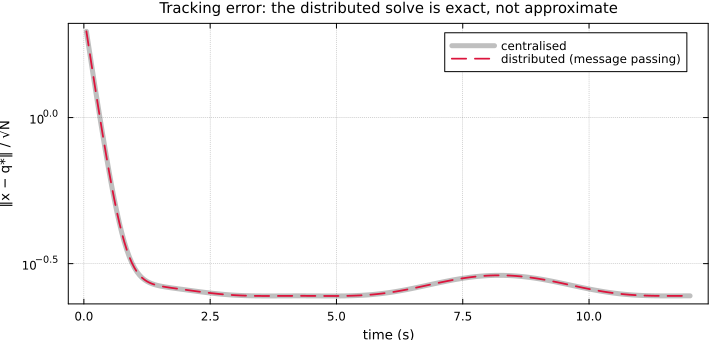

In [9]:
rmprocs(workers_pids)

ts = (1:STEPS) .* DT
plot(ts, err_c; linewidth = 5, color = :black, alpha = 0.25, label = "centralised",
     xlabel = "time (s)", ylabel = "‖x − q*‖ / √N", yscale = :log10, legend = :topright,
     title = "Tracking error: the distributed solve is exact, not approximate")
plot!(ts, err_d; linewidth = 1.8, color = :crimson, linestyle = :dash,
      label = "distributed (message passing)")

## How this scales: memory is the win

Twelve agents is a small problem, since the whole factorisation is a couple of kilobytes and a
hub would handle it comfortably. The argument for distributing only bites once the fleet, or
the per-agent state, grows.

Below we sweep fleet size on a grid formation and record what the **worst** agent must store,
because the worst agent is what sets the hardware spec, not the average. Two stalk dimensions
are shown: $\mathbb{R}^3$ for a point mass, and $\mathbb{R}^{12}$ for a quadrotor's full
state.

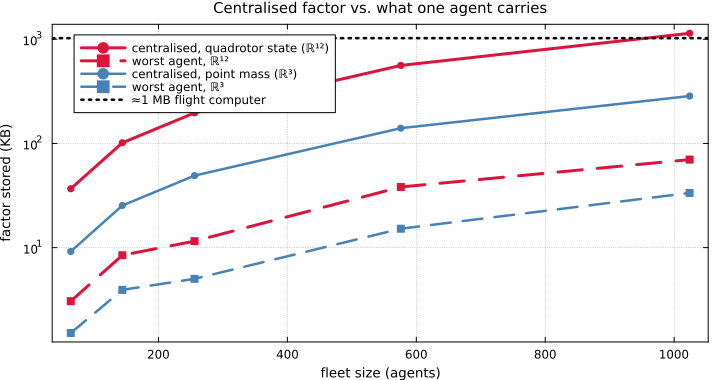

In [10]:
using Graphs

function factor_split(nagents, stalk, nproc)
    g = Graphs.grid([isqrt(nagents), isqrt(nagents)])
    s = EuclideanSheaf{Float64}(fill(stalk, nv(g)))
    Ik = Matrix{Float64}(I, stalk, stalk)
    for e in edges(g)
        add_sheaf_edge!(s, src(e), dst(e), Ik, Ik)
    end
    M = sparse(sheaf_laplacian_matrix(s)) + 1e-1 * I
    Fk = cholesky!(ChordalCholesky(M), NoPivot())
    Pk = partition_tree(Fk.L, nproc)
    nw = length(Pk.chunks)
    central = (length(Fk.L.Dval) + length(Fk.L.Lval)) * sizeof(Float64)
    worst = maximum((length(w.Dval) + length(w.Lval)) * sizeof(Float64)
                    for w in (worker_factorization(Fk.L, Pk, w) for w in 1:nw))
    central, worst
end

fleet = [64, 144, 256, 576, 1024]
res3 = [factor_split(n, 3, 16) for n in fleet]
res12 = [factor_split(n, 12, 16) for n in fleet]

PIXHAWK_KB = 1024.0

p1 = plot(; xlabel = "fleet size (agents)", ylabel = "factor stored (KB)", yscale = :log10,
          legend = :topleft, size = (720, 380),
          title = "Centralised factor vs. what one agent carries")
plot!(p1, fleet, [c / 1024 for (c, _) in res12]; linewidth = 3, color = :crimson,
      marker = :circle, label = "centralised, quadrotor state (ℝ¹²)")
plot!(p1, fleet, [w / 1024 for (_, w) in res12]; linewidth = 3, color = :crimson,
      linestyle = :dash, marker = :square, label = "worst agent, ℝ¹²")
plot!(p1, fleet, [c / 1024 for (c, _) in res3]; linewidth = 2.5, color = :steelblue,
      marker = :circle, label = "centralised, point mass (ℝ³)")
plot!(p1, fleet, [w / 1024 for (_, w) in res3]; linewidth = 2.5, color = :steelblue,
      linestyle = :dash, marker = :square, label = "worst agent, ℝ³")
hline!(p1, [PIXHAWK_KB]; color = :black, linestyle = :dot, linewidth = 2.5,
       label = "≈1 MB flight computer")

The dotted line is a Pixhawk-class memory budget. For quadrotor-dimensional agents the
**centralised** factorisation crosses it and keeps climbing, so a hub could not hold the problem
on flight hardware at all, while the **worst agent** stays comfortably underneath. The share
each agent carries is roughly flat in fleet size, so distributing does not merely help. It is
what makes the coordination layer representable on the vehicles.

## And the constraint: communication rounds follow the topology

The cost that grows is communication. The forward/backward sweeps take $2 \times$ the depth
of the clique tree, and that depth is a property of the **coordination graph**, not of the
solver.

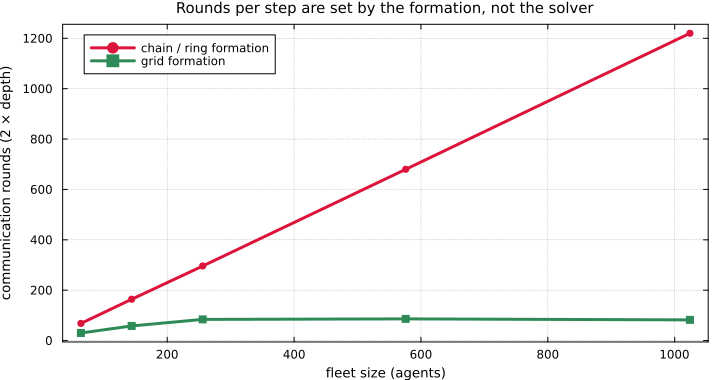

In [11]:
function tree_depth(g, stalk)
    s = EuclideanSheaf{Float64}(fill(stalk, nv(g)))
    Ik = Matrix{Float64}(I, stalk, stalk)
    for e in edges(g)
        add_sheaf_edge!(s, src(e), dst(e), Ik, Ik)
    end
    M = sparse(sheaf_laplacian_matrix(s)) + 1e-1 * I
    S = cholesky!(ChordalCholesky(M), NoPivot()).L.S
    maximum(begin
        k = j; dd = 0
        while S.pnt[k] != 0
            k = S.pnt[k]; dd += 1
        end
        dd
    end for j in 1:nv(S.res)) + 1
end

chain_of(n) = (g = cycle_graph(n); for i in 1:n; add_edge!(g, i, mod1(i + 4, n)); end; g)
grid_of(n) = Graphs.grid([isqrt(n), isqrt(n)])

depth_chain = [2 * tree_depth(chain_of(n), 3) for n in fleet]
depth_grid = [2 * tree_depth(grid_of(n), 3) for n in fleet]

p2 = plot(fleet, depth_chain; linewidth = 3, color = :crimson, marker = :circle,
          label = "chain / ring formation", legend = :topleft, size = (720, 380),
          xlabel = "fleet size (agents)", ylabel = "communication rounds (2 × depth)",
          title = "Rounds per step are set by the formation, not the solver")
plot!(p2, fleet, depth_grid; linewidth = 3, color = :seagreen, marker = :square,
      label = "grid formation")

A grid has good separators, so nested dissection keeps the tree shallow and the round count
nearly **flat** as the fleet grows. A chain has none: its elimination tree degenerates into a
path, the round count grows **linearly**, and message passing becomes the wrong tool.

This is the honest boundary of the method, and it is also a design principle: *if you want
decentralised coordination, choose a consensus topology with good separators.*

## What this demonstrates

- The harmonic extension, the coordination layer of the whole architecture, is computed
  **without any central solver**, by two sweeps of neighbour-to-neighbour messages over the
  clique tree, and it reproduces the centralised controller to machine precision.
- It is **exact**, not iterative. Unlike ADMM or gossip, which approach $q^\star$ only as the
  number of rounds grows, the tree solve terminates with the *exact* answer in a bounded number
  of rounds.
- **No agent stores the whole problem**, and the split is exact, with no block duplicated. This
  is what makes the coordination layer fit on flight hardware as agent state grows.
- The price is communication rounds, governed by the treewidth of the coordination sheaf.

In [12]:
nothing